<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20QGen016.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

N_grid = 256
x = np.linspace(0, 2*np.pi, N_grid, endpoint=False)
A = 0.1
sigma = 0.2
x1, x2 = np.pi/4, 7*np.pi/4
theta = np.pi / 3

def gaussian(center, width, amplitude):
    return amplitude * np.exp(-((x - center)**2) / (2 * width**2))

A1 = gaussian(x1, sigma, A)
A2 = gaussian(x2, sigma, A) * np.cos(theta)
phi = A1 + A2
history = [phi.copy()]


In [2]:
dt = 0.01
gamma = 0.005
lam = 0.1

def laplacian(phi):
    lap = np.roll(phi, 1) - 2*phi + np.roll(phi, -1)
    return np.nan_to_num(lap)

def evolve(phi):
    lap = laplacian(phi)
    nonlinear = lam * np.clip(phi, -1.0, 1.0)**3
    phi = phi + dt * (lap - gamma * phi + nonlinear)
    return np.clip(phi, -1.0, 1.0)

for t in range(300):
    phi = evolve(phi)
    if t == 150:
        phi -= A2  # collapse Node A2
    if t % 50 == 0:
        history.append(phi.copy())


In [3]:
def correlation(a, b):
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return (np.dot(a, b) / denom) if denom > 0 else 0.0

corr_A1 = [correlation(h, A1) for h in history]


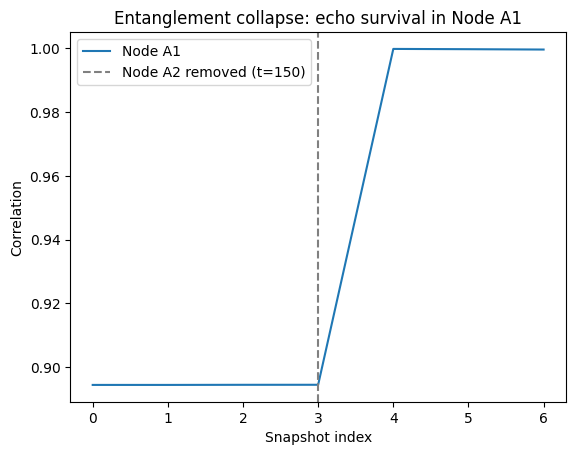

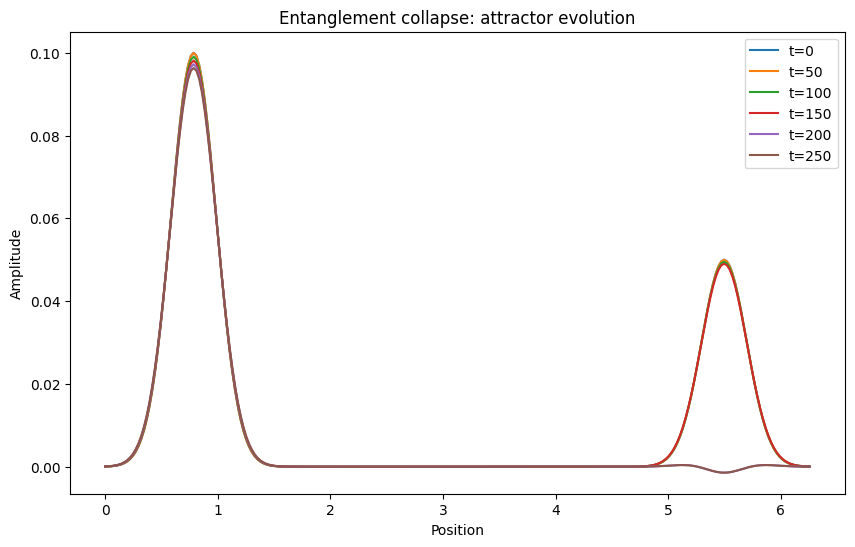

In [4]:
# Correlation plot
plt.plot(corr_A1, label="Node A1")
plt.axvline(x=3, color='gray', linestyle='--', label="Node A2 removed (t=150)")
plt.xlabel("Snapshot index")
plt.ylabel("Correlation")
plt.title("Entanglement collapse: echo survival in Node A1")
plt.legend()
plt.show()

# Amplitude evolution
plt.figure(figsize=(10,6))
for i, h in enumerate(history[:6]):
    plt.plot(x, h, label=f"t={i*50}")
plt.xlabel("Position")
plt.ylabel("Amplitude")
plt.title("Entanglement collapse: attractor evolution")
plt.legend()
plt.show()
